# Fitting a mechanism to transient PRBS data

Steady-state data constrains equilibrium constants and the lumped rate; a **transient** experiment that perturbs the feed identifies the **rate constants** (the dynamics). Here we use **independent** pseudo-random binary sequences (PRBS) for the CO *and* O2 partial pressures (different bit periods, so their switches do not line up), sampled at **irregular measurement times** that align with neither the input switches nor the integration mesh — i.e. a realistic experiment.

The forward model integrates the coverage ODEs with POUNCE's implicit **Radau** solver (`numeric.integrate_coverages`, stiff/DAE-capable), and the fit uses POUNCE's `curve_fit` (confidence intervals + parameter correlation).

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
import pounce
import discopt.mkm as mk
from discopt.mkm import numeric

## Mechanism (fitted: CO-adsorption `A_ads` and surface `A_surf`)

In [2]:
def build(A_ads=30.0, A_surf=1e8):
    """Build the CO-oxidation model used throughout this notebook.

    Parameters
    ----------
    A_ads : float
        Pre-exponential of CO adsorption (the first fitted constant).
    A_surf : float
        Pre-exponential of the surface reaction CO* + O* -> CO2 (the
        second fitted constant).

    Returns ``(model, (CO, O2, CO2, CO*, O*))``.
    """
    m = mk.Model('co_ox', T=500.0, R=8.617e-5)
    s = m.site('*', density=1.0)
    CO, O2, CO2 = m.gas('CO'), m.gas('O2'), m.gas('CO2')
    COs, Os = m.adsorbate('CO*', site=s), m.adsorbate('O*', site=s)
    m.step(CO + s >> COs, A=A_ads, Ea=0.0)
    m.step(O2 + 2*s >> 2*Os, A=30.0, Ea=0.0)
    m.step(COs + Os >> CO2 + 2*s, A=A_surf, Ea=0.7)
    return m, (CO, O2, CO2, COs, Os)

## Independent CO and O2 PRBS inputs, and irregular sample times

The combined input is piecewise-constant on the **union** of both sequences' switch times; we integrate one constant segment per interval and carry the coverages across.

In [3]:
def prbs(tend, tbit, lo, hi, seed):
    """Generate a pseudo-random binary sequence (PRBS) input.

    Parameters
    ----------
    tend : float
        Total duration of the sequence.
    tbit : float
        Bit (hold) period; the level may switch only every ``tbit``.
    lo, hi : float
        The two levels the signal toggles between.
    seed : int
        Random seed for the bit pattern.

    Returns ``(edges, values)`` where ``values[i]`` is held on the interval
    ``[edges[i], edges[i + 1])``.
    """
    r = np.random.default_rng(seed); n = int(np.ceil(tend/tbit))
    return np.arange(n+1)*tbit, np.where(r.integers(0,2,n), hi, lo).astype(float)

TEND = 2.0
eCO, vCO = prbs(TEND, 0.10, 0.5, 1.5, 1)   # CO: bit period 0.10
eO2, vO2 = prbs(TEND, 0.13, 0.3, 0.7, 2)   # O2: bit period 0.13 (unaligned)
breaks = np.unique(np.r_[eCO, eO2, 0, TEND]); breaks = breaks[(breaks>=0) & (breaks<=TEND+1e-9)]
segs = [(breaks[i], breaks[i+1]) for i in range(len(breaks)-1)]
val = lambda e, v, t: v[min(max(np.searchsorted(e, t, 'right')-1, 0), len(v)-1)]
segCO = [float(val(eCO, vCO, (a+b)/2)) for a, b in segs]
segO2 = [float(val(eO2, vO2, (a+b)/2)) for a, b in segs]
rng = np.random.default_rng(7)
t_meas = np.sort(rng.uniform(0.02, TEND, 90))   # irregular sample times
print(f'{len(segs)} input segments, {len(t_meas)} irregular samples')

34 input segments, 90 irregular samples


## Forward model: per-segment implicit-Radau integration, interpolated to the sample times

In [4]:
def simulate(A_ads, A_surf, return_curve=False):
    """Integrate the CO2 turnover response to the two PRBS inputs.

    Integrates the coverages one piecewise-constant input segment at a time
    (implicit Radau), carrying coverages across segment boundaries.

    Parameters
    ----------
    A_ads, A_surf : float
        The two pre-exponentials being estimated.
    return_curve : bool
        If True, return the dense ``(t, r_CO2)`` trajectory; otherwise
        return the response interpolated at the irregular sample times ``t_meas``.
    """
    m, (CO, O2, CO2, COs, Os) = build(A_ads, A_surf); site = m.sites[0]
    tg, rg, theta = [], [], {COs: 0.0, Os: 0.0}
    for (a, b), Pco, Po2 in zip(segs, segCO, segO2):
        conc = {CO: Pco, O2: Po2, CO2: 0.0}
        sol = numeric.integrate_coverages(m, conc, 500.0, np.linspace(a, b, 4), theta0=theta)
        for k in range(len(sol.t)):
            th = {COs: sol.y[0, k], Os: sol.y[1, k]}; free = {site: 1 - th[COs] - th[Os]}
            rg.append(numeric.turnover_frequency(m, CO2, th, free, conc, 500.0)); tg.append(sol.t[k])
        theta = {COs: sol.y[0, -1], Os: sol.y[1, -1]}
    tg, rg = np.array(tg), np.array(rg); o = np.argsort(tg)
    if return_curve: return tg[o], rg[o]
    return np.interp(t_meas, tg[o], rg[o])   # observable at the irregular sample times

tg, rg = simulate(30.0, 1e8, return_curve=True)
r_true = np.interp(t_meas, tg, rg)
data = r_true + rng.normal(0, 0.03 * r_true.std(), r_true.shape)

/var/folders/sj/cb6cr7_s45d67mqjmsfx8mt80000gn/T/ipykernel_9048/1614575825.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax[0].set_title('independent CO / O2 PRBS inputs and the sampled CO2 response'); fig.show()


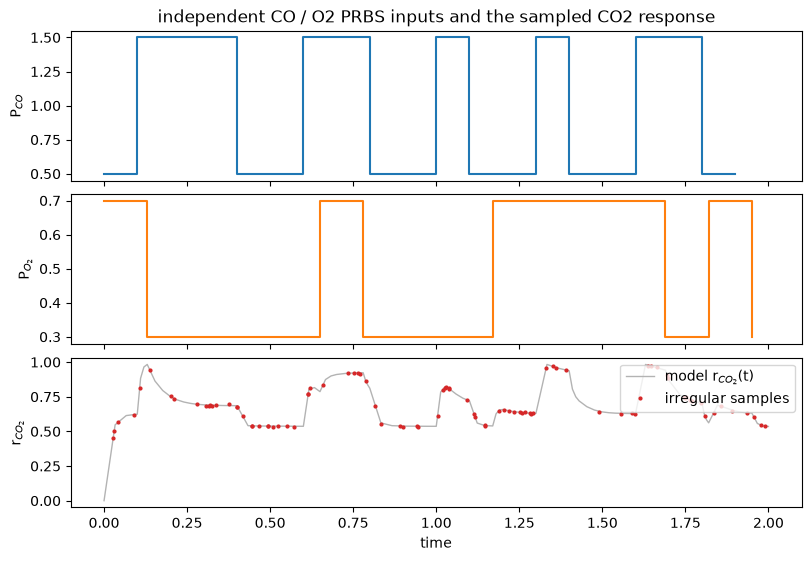

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), sharex=True, layout='constrained')
ax[0].step(eCO[:-1], vCO, where='post', color='C0'); ax[0].set_ylabel('P$_{CO}$')
ax[1].step(eO2[:-1], vO2, where='post', color='C1'); ax[1].set_ylabel('P$_{O_2}$')
ax[2].plot(tg, rg, '-', color='0.7', lw=1, label='model r$_{CO_2}$(t)')
ax[2].plot(t_meas, data, '.', ms=4, color='C3', label='irregular samples')
ax[2].set_ylabel('r$_{CO_2}$'); ax[2].set_xlabel('time'); ax[2].legend(loc='upper right')
ax[0].set_title('independent CO / O2 PRBS inputs and the sampled CO2 response'); fig.show()

## Fit with POUNCE `curve_fit` (confidence intervals + correlation)

In [6]:
def model(x, logA_ads, logA_surf):
    """Forward model for ``pounce.curve_fit``.

    Maps base-10 log pre-exponentials to the predicted CO2 response at the
    sample points. ``x`` is the index vector ``curve_fit`` passes and is
    unused (the sampling times are captured in ``t_meas``).
    """
    return simulate(10**logA_ads, 10**logA_surf)

res = pounce.curve_fit(model, np.arange(len(data)), data, p0=[1.0, 7.3])
A_ads_fit, A_surf_fit = 10**res.popt[0], 10**res.popt[1]
print(f'true   :  A_ads = 30,    A_surf = 1.0e8')
print(f'fitted :  A_ads = {A_ads_fit:.3g},  A_surf = {A_surf_fit:.3g}')
print(f'R^2 = {res.r_squared:.4f};  log10-param 95% CIs = {np.round(np.asarray(res.ci),3).tolist()}')
print('parameter correlation:\n', np.round(np.asarray(res.correlation), 3))

.../site-packages/pounce/_curve_fit.py:924: UserWarning: pounce.curve_fit: using a finite-difference Jacobian (model is not JAX-traceable and no analytic jac given). Pass jac=<callable> or write the model with jax.numpy for exact derivatives; covariance and sensitivity are most accurate then.
  prob = _build_fit_problem(


true   :  A_ads = 30,    A_surf = 1.0e8
fitted :  A_ads = 30.5,  A_surf = 9.98e+07
R^2 = 0.9993;  log10-param 95% CIs = [[1.477, 1.491], [7.999, 8.0]]
parameter correlation:
 [[ 1.    -0.285]
 [-0.285  1.   ]]


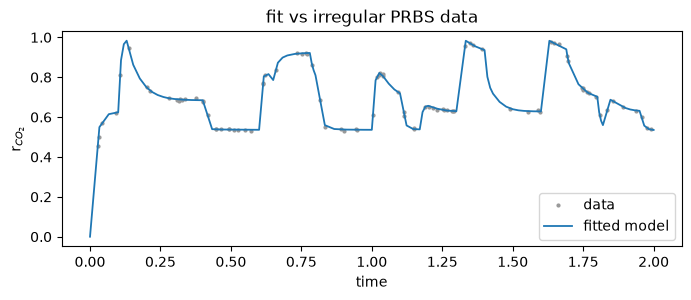

In [7]:
tgf, rgf = simulate(A_ads_fit, A_surf_fit, return_curve=True)
plt.figure(figsize=(8, 2.8))
plt.plot(t_meas, data, '.', ms=4, color='0.6', label='data')
plt.plot(tgf, rgf, '-', color='C0', lw=1.3, label='fitted model')
plt.xlabel('time'); plt.ylabel('r$_{CO_2}$'); plt.legend(); plt.title('fit vs irregular PRBS data'); plt.show()

## Analytic trajectory sensitivities with `pounce.jax.odeint`

POUNCE also provides a *differentiable* integrator: the gradient of the coverage trajectory w.r.t. the kinetic parameters is exact (implicit-function theorem on each Radau step), not finite-differenced. Here is the analytic sensitivity of $\theta_{CO^*}(t)$ to each pre-exponential over one segment.

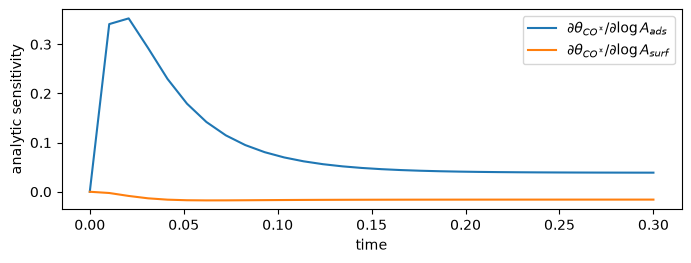

In [8]:
import jax, jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
from pounce.jax import odeint as jodeint
RT, Ea3 = 8.617e-5*500.0, 0.7
def rhs(t, y, th):
    """Coverage ODE right-hand side for the JAX sensitivity demo.

    Parameters
    ----------
    t : float
        Time (unused; the system is autonomous).
    y : array ``[theta_CO, theta_O]``
        Current CO* and O* coverages.
    th : array ``[log10 A_ads, log10 A_surf]``
        Parameters to differentiate with respect to (K_eq = 1 here).
    """
    A_ads, kf3 = 10**th[0], (10**th[1])*jnp.exp(-Ea3/RT)
    thCO, thO = y[0], y[1]; free = 1 - thCO - thO
    return jnp.array([A_ads*(1.0*free - thCO) - kf3*thCO*thO,
                      2*30.0*(0.5*free**2 - thO**2) - kf3*thCO*thO])
tm = np.linspace(0, 0.3, 30)
thetaCO = lambda th: jodeint(rhs, jnp.array([0.0, 0.0]), tm, th).y[0]
th0 = jnp.array([np.log10(30.0), 8.0])
S = np.asarray(jax.jacobian(thetaCO)(th0))   # d theta_CO*(t) / d[logA_ads, logA_surf]
plt.figure(figsize=(8, 2.6))
plt.plot(tm, S[:, 0], label=r'$\partial\theta_{CO^*}/\partial\log A_{ads}$')
plt.plot(tm, S[:, 1], label=r'$\partial\theta_{CO^*}/\partial\log A_{surf}$')
plt.xlabel('time'); plt.ylabel('analytic sensitivity'); plt.legend(); plt.show()

## Takeaways

- **Independent multi-input PRBS** is handled by integrating one constant segment per interval on the *union* of the inputs' switch times, carrying coverages across.
- **Irregular sample times** decouple from the integration mesh: the model response is interpolated to the actual measurement times, so any sampling schedule works.
- The forward solve uses POUNCE's implicit **Radau** integrator (stiff/DAE-capable), and `curve_fit` returns **confidence intervals** and the **parameter correlation** (here the two pre-exponentials are mildly anti-correlated).
- POUNCE's `pounce.jax.odeint` gives **analytic** trajectory sensitivities, the exact-derivative basis for gradient-based estimation.
- Caveat: at one temperature only rate constants $k = A\,e^{-E_a/RT}$ are identifiable, not $A$ and $E_a$ separately — multi-temperature data (the steady-state `fit_kinetics` bridge) separates them.